# EDA — Synthetic Fraud Detection

Two datasets are built from `synthetic_fraud_data.csv` (~7.48M rows, 24 cols, ~2.9 GB):

| name | description | fraud rate |
|------|-------------|-----------|
| `df` | reproducible **300k** random sample (`random_state=1`), read memory-safely | ~20% (synthetic) |
| `transaction_sampled_v2` | a copy of `df` with **fraud randomly down-sampled** (`random_state=1`) to a realistic imbalance | ~0.75% (in the real-world 0.5–1% band) |

All EDA below follows `EDA_CHECKLIST.md` and is run on `transaction_sampled_v2`.

## 0. Imports & Setup

In [1]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

%matplotlib inline
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

SAMPLE_SIZE = 300_000
RANDOM_STATE = 1

# Locate the dataset (notebook usually runs from .../src, file lives one level up)
_CANDIDATES = [
    "../synthetic_fraud_data.csv",
    "synthetic_fraud_data.csv",
    os.path.join("..", "..", "synthetic_fraud_data.csv"),
]
DATA_PATH = next((p for p in _CANDIDATES if os.path.exists(p)), _CANDIDATES[0])
print("Dataset path:", os.path.abspath(DATA_PATH))

Dataset path: C:\Users\Thang Ngoc Nguyen\Downloads\AI_thucchien\Phase3_Internship\smart-finance-ai\synthetic_fraud_data.csv


## 1. Load a reproducible 300k sample (`df`)

Count the data rows once, draw 300,000 unique row indices with a seeded RNG (`random_state=1`), and read **only** those rows via `skiprows`. Deterministic and memory-safe — the full 2.9 GB file is never held in a DataFrame.

In [2]:
# Count data rows (excludes the header line)
with open(DATA_PATH, "rb") as f:
    n_total = sum(1 for _ in f) - 1
print(f"Total data rows in file: {n_total:,}")

rng = np.random.RandomState(RANDOM_STATE)
keep_idx = np.sort(rng.choice(n_total, size=SAMPLE_SIZE, replace=False))

# File line numbers to skip (line 0 is the header, so data row j -> file line j+1)
skip_lines = np.setdiff1d(np.arange(n_total), keep_idx) + 1

df = pd.read_csv(DATA_PATH, skiprows=skip_lines)
print(f"Sample shape: {df.shape}")
df.head()

Total data rows in file: 7,483,766


Sample shape: (300000, 24)


,transaction_id,customer_id,card_number,timestamp,merchant_category,merchant_type,merchant,amount,currency,country,city,city_size,card_type,card_present,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
0,TX_96c732ec,CUST_65989,4135745832575997,2024-09-30 00:00:07.780617+00:00,Healthcare,pharmacy,DuaneReade,529.57,EUR,France,Unknown City,medium,Gold Credit,False,Edge,web,77bb34bbf13ff6459c916f6a410c3dcf,241.85.54.78,0,False,0,False,"{'num_transactions': 600, 'total_amount': 1766...",False
1,TX_5595b6f4,CUST_79361,6219138778768079,2024-09-30 00:00:21.797955+00:00,Grocery,online,Walmart Grocery,47292.58,JPY,Japan,Unknown City,medium,Gold Credit,False,Safari,web,032b22b43e1beca9d9d5300c0afa7921,192.99.224.88,0,False,0,False,"{'num_transactions': 143, 'total_amount': 8100...",False
2,TX_9535a387,CUST_84592,6377830522299744,2024-09-30 00:00:33.655044+00:00,Travel,booking,Hotels.com,974.78,SGD,Singapore,Unknown City,medium,Premium Debit,False,Chrome,web,8d304f9e967a9ec5faec07df14b8820a,251.151.135.13,0,True,0,False,"{'num_transactions': 548, 'total_amount': 1603...",False
3,TX_f1b1c47b,CUST_13443,5923978083885384,2024-09-30 00:00:40.563229+00:00,Education,online,Udemy,72148.62,NGN,Nigeria,Unknown City,medium,Basic Debit,False,Safari,web,48956de027a5c742f856d694df88f652,136.77.127.63,0,False,0,False,"{'num_transactions': 1495, 'total_amount': 161...",False
4,TX_8f838821,CUST_73541,6787367881679970,2024-09-30 00:01:25.314780+00:00,Travel,airlines,American Airlines,457.96,EUR,France,Unknown City,medium,Premium Debit,False,Chrome,web,12c2caecef6b2556c4593d3f84cdeffc,16.198.139.181,0,True,0,False,"{'num_transactions': 263, 'total_amount': 9389...",False


In [3]:
# Original fraud balance in the 300k sample
print(df["is_fraud"].value_counts())
print(f"\nFraud rate: {df['is_fraud'].mean() * 100:.3f}%")

is_fraud
False    239857
True      60143
Name: count, dtype: int64

Fraud rate: 20.048%


## 2. Build `transaction_sampled_v2` — realistic class imbalance

The 300k sample is ~20% fraud, far higher than the **0.5–1%** seen in real card-transaction data. We keep **all** legitimate rows and **randomly down-sample the fraud rows** (`random_state=1`) so fraud lands at a target rate inside that band, then shuffle.

For a target rate *p* with `n_legit` legitimate rows, the number of fraud rows to keep is
`n_fraud_keep = round(p / (1 - p) * n_legit)`.

In [4]:
TARGET_FRAUD_RATE = 0.0075  # 0.75% -> middle of the real-world 0.5%-1% band

legit = df[~df["is_fraud"]]
fraud = df[df["is_fraud"]]

n_fraud_keep = int(round(TARGET_FRAUD_RATE / (1 - TARGET_FRAUD_RATE) * len(legit)))
fraud_down = fraud.sample(n=n_fraud_keep, random_state=RANDOM_STATE)

transaction_sampled_v2 = (
    pd.concat([legit, fraud_down])
    .sample(frac=1, random_state=RANDOM_STATE)   # shuffle so fraud isn't clustered at the end
    .reset_index(drop=True)
)

print(f"legit rows kept : {len(legit):,}")
print(f"fraud rows kept : {n_fraud_keep:,} (of {len(fraud):,})")
print(f"v2 shape        : {transaction_sampled_v2.shape}")
print(f"v2 fraud rate   : {transaction_sampled_v2['is_fraud'].mean() * 100:.3f}%")
transaction_sampled_v2["is_fraud"].value_counts()

legit rows kept : 239,857
fraud rows kept : 1,813 (of 60,143)
v2 shape        : (241670, 24)
v2 fraud rate   : 0.750%


is_fraud
False    239857
True       1813
Name: count, dtype: int64

In [5]:
# Persist the realistic-imbalance copy next to the source data for reuse
V2_PATH = os.path.join(os.path.dirname(DATA_PATH), "transaction_sampled_v2.csv")
transaction_sampled_v2.to_csv(V2_PATH, index=False)
print("Saved:", os.path.abspath(V2_PATH))

Saved: C:\Users\Thang Ngoc Nguyen\Downloads\AI_thucchien\Phase3_Internship\smart-finance-ai\transaction_sampled_v2.csv


---
# EDA on `transaction_sampled_v2` (following `EDA_CHECKLIST.md`)

We work on a copy, `tx`, so the saved dataset stays untouched.

In [6]:
tx = transaction_sampled_v2.copy()

## EDA-1. Data Understanding
High-level feel for shape and contents before touching anything.

In [7]:
print("shape:", tx.shape)
tx.head()

shape: (241670, 24)


,transaction_id,customer_id,card_number,timestamp,merchant_category,merchant_type,merchant,amount,currency,country,city,city_size,card_type,card_present,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
0,TX_ad2cfa31,CUST_93025,4203545253921598,2024-10-05 10:14:25.068163+00:00,Gas,major,Shell,483.24,EUR,France,Unknown City,medium,Platinum Credit,False,iOS App,mobile,4e2542161c74343841e70e54f05b7e72,223.93.55.73,1,False,10,True,"{'num_transactions': 540, 'total_amount': 6504...",False
1,TX_bfb366ce,CUST_17882,5293103549189139,2024-10-19 06:07:46.168915+00:00,Healthcare,medical,Local Hospital,22479.74,RUB,Russia,Unknown City,medium,Premium Debit,False,Edge,web,777705da49eb63538590fdb57354951e,82.249.216.73,0,False,6,True,"{'num_transactions': 558, 'total_amount': 3711...",False
2,TX_e302ab95,CUST_45684,5148263615010325,2024-10-04 15:39:56.108096+00:00,Travel,hotels,Hilton,13094.66,MXN,Mexico,Unknown City,medium,Basic Debit,False,Chrome,web,f4e56b8db9932e97919cf41f66588ab1,231.6.123.198,0,True,15,False,"{'num_transactions': 282, 'total_amount': 5707...",False
3,TX_100f054b,CUST_30366,5370429387514625,2024-10-24 03:17:54.073630+00:00,Retail,physical,Nike Store,1034.47,EUR,Germany,Unknown City,medium,Platinum Credit,False,Chrome,web,809995b3a54370411073d192207240e0,94.60.173.85,0,False,3,False,"{'num_transactions': 189, 'total_amount': 1281...",False
4,TX_a74c90e0,CUST_52620,379005484000098,2024-10-07 19:36:03.934214+00:00,Healthcare,pharmacy,DuaneReade,690.07,EUR,Germany,Unknown City,medium,Platinum Credit,False,Firefox,web,cdc55c199a47cfc33c816462eaaf2ecb,33.64.196.127,0,False,19,False,"{'num_transactions': 705, 'total_amount': 2094...",False


In [8]:
print("columns:")
list(tx.columns)

columns:


['transaction_id',
 'customer_id',
 'card_number',
 'timestamp',
 'merchant_category',
 'merchant_type',
 'merchant',
 'amount',
 'currency',
 'country',
 'city',
 'city_size',
 'card_type',
 'card_present',
 'device',
 'channel',
 'device_fingerprint',
 'ip_address',
 'distance_from_home',
 'high_risk_merchant',
 'transaction_hour',
 'weekend_transaction',
 'velocity_last_hour',
 'is_fraud']

In [9]:
tx.dtypes

transaction_id          object
customer_id             object
card_number              int64
timestamp               object
merchant_category       object
merchant_type           object
merchant                object
amount                 float64
currency                object
country                 object
city                    object
city_size               object
card_type               object
card_present              bool
device                  object
channel                 object
device_fingerprint      object
ip_address              object
distance_from_home       int64
high_risk_merchant        bool
transaction_hour         int64
weekend_transaction       bool
velocity_last_hour      object
is_fraud                  bool
dtype: object

In [10]:
tx.describe()

,card_number,amount,distance_from_home,transaction_hour
count,2.416700e+05,2.416700e+05,241670.000000,241670.000000
mean,4.227241e+15,3.077964e+04,0.178624,13.031903
std,2.339880e+15,9.132547e+04,0.383038,6.073611
min,3.700086e+14,2.000000e-02,0.000000,0.000000
25%,4.006741e+15,3.692625e+02,0.000000,8.000000
50%,5.011677e+15,9.146300e+02,0.000000,13.000000
75%,6.004355e+15,1.492832e+04,0.000000,18.000000
max,6.999728e+15,5.640872e+06,1.000000,23.000000


## EDA-2. Data Preparation (Cleaning)

### Subset columns
Drop near-unique identifiers that carry no analytical signal *before* cleaning.

In [11]:
# Identifier / high-cardinality columns -> drop for EDA (kept in the saved v2 CSV).
# Filtered to columns that exist so it's robust if customer_id was already removed upstream.
id_cols = [c for c in ["transaction_id", "customer_id", "card_number",
                       "device_fingerprint", "ip_address"] if c in tx.columns]
print("Uniqueness of candidate id columns (n_unique / n_rows):")
for c in id_cols:
    print(f"  {c:20s} {tx[c].nunique():>7,} / {len(tx):,}")

tx = tx.drop(columns=id_cols).copy()
print("\nRemaining columns:", tx.shape[1])
list(tx.columns)

Uniqueness of candidate id columns (n_unique / n_rows):


  transaction_id       241,661 / 241,670


  customer_id            4,869 / 241,670
  card_number            5,000 / 241,670


  device_fingerprint    11,780 / 241,670


  ip_address           241,663 / 241,670



Remaining columns:

 19


['timestamp',
 'merchant_category',
 'merchant_type',
 'merchant',
 'amount',
 'currency',
 'country',
 'city',
 'city_size',
 'card_type',
 'card_present',
 'device',
 'channel',
 'distance_from_home',
 'high_risk_merchant',
 'transaction_hour',
 'weekend_transaction',
 'velocity_last_hour',
 'is_fraud']

### Fix data types
- `timestamp` -> datetime (and derive a few calendar features)
- `velocity_last_hour` is a **stringified dict** -> parse and expand into numeric columns

In [12]:
# timestamp -> datetime + calendar features
tx["timestamp"] = pd.to_datetime(tx["timestamp"], format="mixed")
tx["date"] = tx["timestamp"].dt.date
tx["day_of_week"] = tx["timestamp"].dt.day_name()

# velocity_last_hour: "{'num_transactions': .., 'total_amount': .., ...}" -> numeric cols
vel = pd.json_normalize(tx["velocity_last_hour"].apply(ast.literal_eval))
vel.columns = ["vel_" + c for c in vel.columns]
tx = pd.concat([tx.drop(columns=["velocity_last_hour"]), vel], axis=1)

print("velocity expanded into:", list(vel.columns))
tx[["timestamp", "day_of_week"] + list(vel.columns)].head()

velocity expanded into: ['vel_num_transactions', 'vel_total_amount', 'vel_unique_merchants', 'vel_unique_countries', 'vel_max_single_amount']


,timestamp,day_of_week,vel_num_transactions,vel_total_amount,vel_unique_merchants,vel_unique_countries,vel_max_single_amount
0,2024-10-05 10:14:25.068163+00:00,Saturday,540,6.504875e+07,104,12,1.769037e+06
1,2024-10-19 06:07:46.168915+00:00,Saturday,558,3.711168e+07,102,12,5.803627e+06
2,2024-10-04 15:39:56.108096+00:00,Friday,282,5.707981e+06,95,12,9.685359e+05
3,2024-10-24 03:17:54.073630+00:00,Thursday,189,1.281867e+07,86,11,4.458354e+06
4,2024-10-07 19:36:03.934214+00:00,Monday,705,2.094897e+07,105,12,3.149159e+06


### Rename columns
Names are already clean `snake_case`, so no renaming is needed — we only standardise the boolean dtypes to integers for correlation work later.

In [13]:
bool_cols = tx.select_dtypes("bool").columns.tolist()
print("boolean columns:", bool_cols)
tx[bool_cols] = tx[bool_cols].astype(int)
tx.dtypes

boolean columns: ['card_present', 'high_risk_merchant', 'weekend_transaction', 'is_fraud']


timestamp                datetime64[ns, UTC]
merchant_category                     object
merchant_type                         object
merchant                              object
amount                               float64
currency                              object
country                               object
city                                  object
city_size                             object
card_type                             object
card_present                           int64
device                                object
channel                               object
distance_from_home                     int64
high_risk_merchant                     int64
transaction_hour                       int64
weekend_transaction                    int64
is_fraud                               int64
date                                  object
day_of_week                           object
vel_num_transactions                   int64
vel_total_amount                     float64
vel_unique

### Missing values

In [14]:
na = tx.isna().sum()
na[na > 0] if (na > 0).any() else "No missing values in any column."

'No missing values in any column.'

### Duplicates
Identifiers were dropped, so we check for fully-duplicated rows on the remaining business columns.

In [15]:
n_dup = tx.duplicated().sum()
print("fully-duplicated rows:", n_dup)
if n_dup:
    display(tx.loc[tx.duplicated(keep=False)].head())

fully-duplicated rows: 0


## EDA-2b. Data leakage check (find perfect-separator columns)

Before trusting any feature, screen for **target leakage** — a column whose value(s) deterministically reveal `is_fraud`. We flag any column that has a value with a **0% or 100% fraud rate** on non-trivial support; a cardinality cap (plus the earlier id-drop) keeps near-unique identifier columns from flagging trivially.

In [16]:
def find_leaky_columns(data, target="is_fraud", max_cardinality=50, min_support=50):
    """Flag columns with a value that is (almost) exclusively one class."""
    flagged = {}
    skip = {target, "timestamp", "date"}
    for col in data.columns:
        if col in skip or data[col].nunique(dropna=False) > max_cardinality:
            continue
        stats = data.groupby(col)[target].agg(fraud_rate="mean", n="count")
        perfect = stats[((stats["fraud_rate"] == 1.0) | (stats["fraud_rate"] == 0.0))
                        & (stats["n"] >= min_support)]
        if len(perfect):
            flagged[col] = perfect
    return flagged


leaks = find_leaky_columns(tx)
LEAK_COLS = sorted(leaks)
print("Leaked (perfect-separator) columns:", LEAK_COLS)
for col, perfect in leaks.items():
    print(f"\n--- {col}: value(s) that perfectly predict is_fraud ---")
    print(perfect)

Leaked (perfect-separator) columns: ['card_present', 'channel', 'device']

--- card_present: value(s) that perfectly predict is_fraud ---
              fraud_rate    n
card_present                 
1                    1.0  785

--- device: value(s) that perfectly predict is_fraud ---
                 fraud_rate    n
device                          
Chip Reader             1.0  254
Magnetic Stripe         1.0  258
NFC Payment             1.0  273

--- channel: value(s) that perfectly predict is_fraud ---
         fraud_rate    n
channel                 
pos             1.0  785


### Confirm the leak on the original full dataset

The flags come from the 300k-based sample, so confirm they are not a sampling artifact by streaming just the relevant columns across **all ~7.48M rows** of the original `synthetic_fraud_data.csv` (chunked, so memory stays low).

In [17]:
# Stream only the flagged columns + target through the full file and accumulate crosstabs.
leak_xtab = {c: None for c in LEAK_COLS}
for chunk in pd.read_csv(DATA_PATH, usecols=LEAK_COLS + ["is_fraud"], chunksize=1_000_000):
    for c in LEAK_COLS:
        ct = pd.crosstab(chunk[c], chunk["is_fraud"])
        leak_xtab[c] = ct if leak_xtab[c] is None else leak_xtab[c].add(ct, fill_value=0)

for c in LEAK_COLS:
    ct = leak_xtab[c].astype("int64").reindex(columns=[False, True], fill_value=0)
    total = ct[False] + ct[True]
    ct["fraud_rate_%"] = (ct[True] / total * 100).round(3)
    print(f"\n=== {c} vs is_fraud — FULL dataset ({int(total.sum()):,} rows) ===")
    print(ct)


=== card_present vs is_fraud — FULL dataset (7,483,766 rows) ===
is_fraud        False    True  fraud_rate_%
card_present                               
False         5989047  843672        12.348
True                0  651047       100.000

=== channel vs is_fraud — FULL dataset (7,483,766 rows) ===
is_fraud    False    True  fraud_rate_%
channel                                
mobile    1988428  281150        12.388
pos             0  651047       100.000
web       4000619  562522        12.328

=== device vs is_fraud — FULL dataset (7,483,766 rows) ===
is_fraud           False    True  fraud_rate_%
device                                        
Android App       985273  140844        12.507
Chip Reader            0  217324       100.000
Chrome            992297  140087        12.371
Edge             1050675  138885        11.675
Firefox           978781  142171        12.683
Magnetic Stripe        0  217204       100.000
NFC Payment            0  216519       100.000
Safari        

> These leaked columns are **kept in `tx` for the EDA below** (so the plots can show the pattern), **excluded from the association / mutual-information analysis**, and **dropped into a leak-free `tx_model`** in *§6. Remove leaked columns*.

## EDA-3. Feature Understanding (Univariate)

> **Note on `amount`:** values are in each transaction's **local `currency`** (JPY, NGN, GBP, ...), not a common unit, so raw cross-currency comparison is misleading. We view it on a log scale.

In [18]:
cat_cols = ["merchant_category", "card_type", "channel", "country", "currency", "day_of_week"]
for c in cat_cols:
    print(f"===== {c} (n_unique={tx[c].nunique()}) =====")
    print(tx[c].value_counts().head(10), "\n")

===== merchant_category (n_unique=8) =====
merchant_category
Retail           30404
Travel           30396
Entertainment    30314
Education        30297
Healthcare       30215
Gas              30170
Grocery          30070
Restaurant       29804
Name: count, dtype: int64 

===== card_type (n_unique=5) =====
card_type
Basic Debit        49737
Premium Debit      49713
Platinum Credit    49570
Gold Credit        46849
Basic Credit       45801
Name: count, dtype: int64 

===== channel (n_unique=3) =====
channel
web       160655
mobile     80230
pos          785
Name: count, dtype: int64 

===== country (n_unique=12) =====
country
Nigeria      22473
Singapore    21994
Brazil       20659
France       20301
UK           20251
Russia       20179
Mexico       19792
Canada       19768
Germany      19701
Japan        19595
Name: count, dtype: int64 

===== currency (n_unique=11) =====
currency
EUR    40002
NGN    22473
SGD    21994
BRL    20659
GBP    20251
RUB    20179
MXN    19792
CAD    19768
J

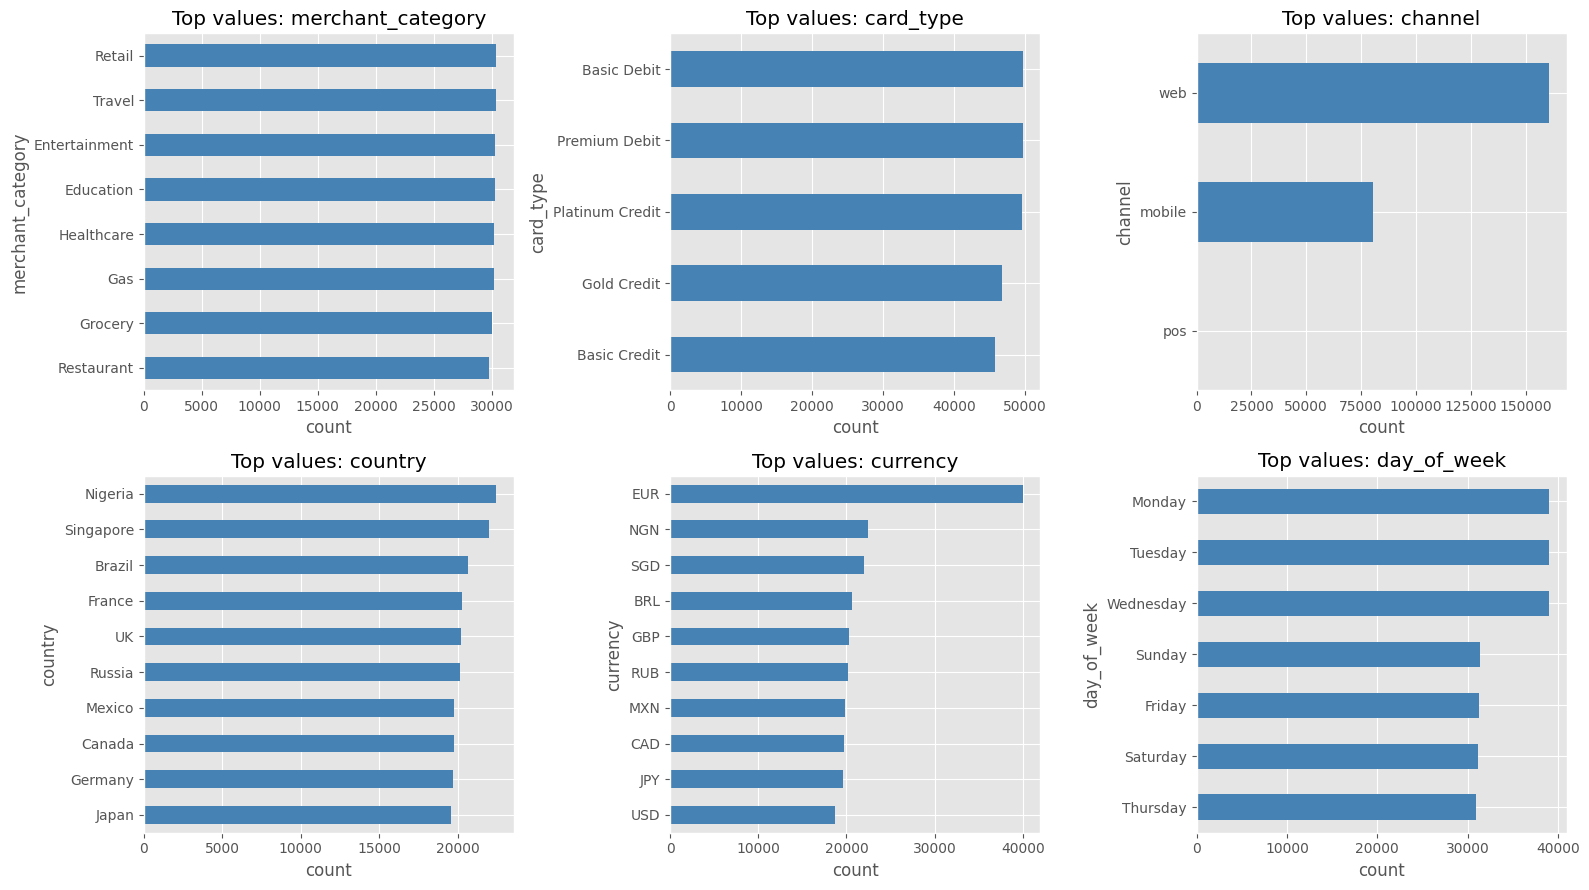

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, c in zip(axes.ravel(), cat_cols):
    tx[c].value_counts().head(10).iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Top values: {c}")
    ax.set_xlabel("count")
    ax.set_ylabel(c)
fig.tight_layout()
plt.show()

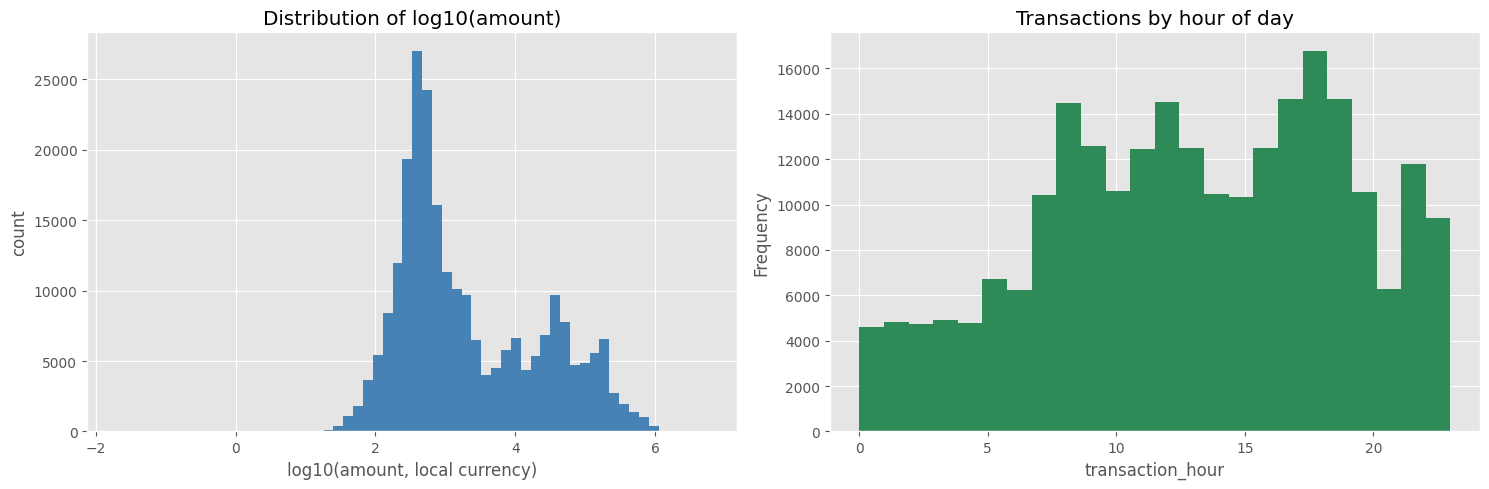

In [20]:
# amount is hugely skewed and mixes currencies -> log10 view
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
log_amt = np.log10(tx["amount"].clip(lower=0.01))
axes[0].hist(log_amt, bins=60, color="steelblue")
axes[0].set_title("Distribution of log10(amount)")
axes[0].set_xlabel("log10(amount, local currency)")
axes[0].set_ylabel("count")

tx["transaction_hour"].plot(kind="hist", bins=24, ax=axes[1], color="seagreen")
axes[1].set_title("Transactions by hour of day")
axes[1].set_xlabel("transaction_hour")
fig.tight_layout()
plt.show()

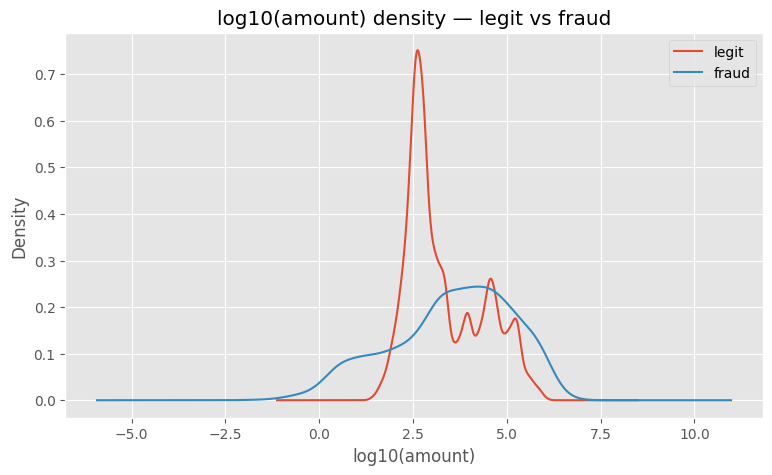

In [21]:
# KDE of log10(amount): legit vs fraud
fig, ax = plt.subplots(figsize=(9, 5))
for label, grp in tx.groupby("is_fraud"):
    np.log10(grp["amount"].clip(lower=0.01)).plot(
        kind="kde", ax=ax, label=("fraud" if label else "legit"))
ax.set_title("log10(amount) density — legit vs fraud")
ax.set_xlabel("log10(amount)")
ax.legend()
plt.show()

## EDA-4. Feature Relationships (Bivariate / Multivariate)

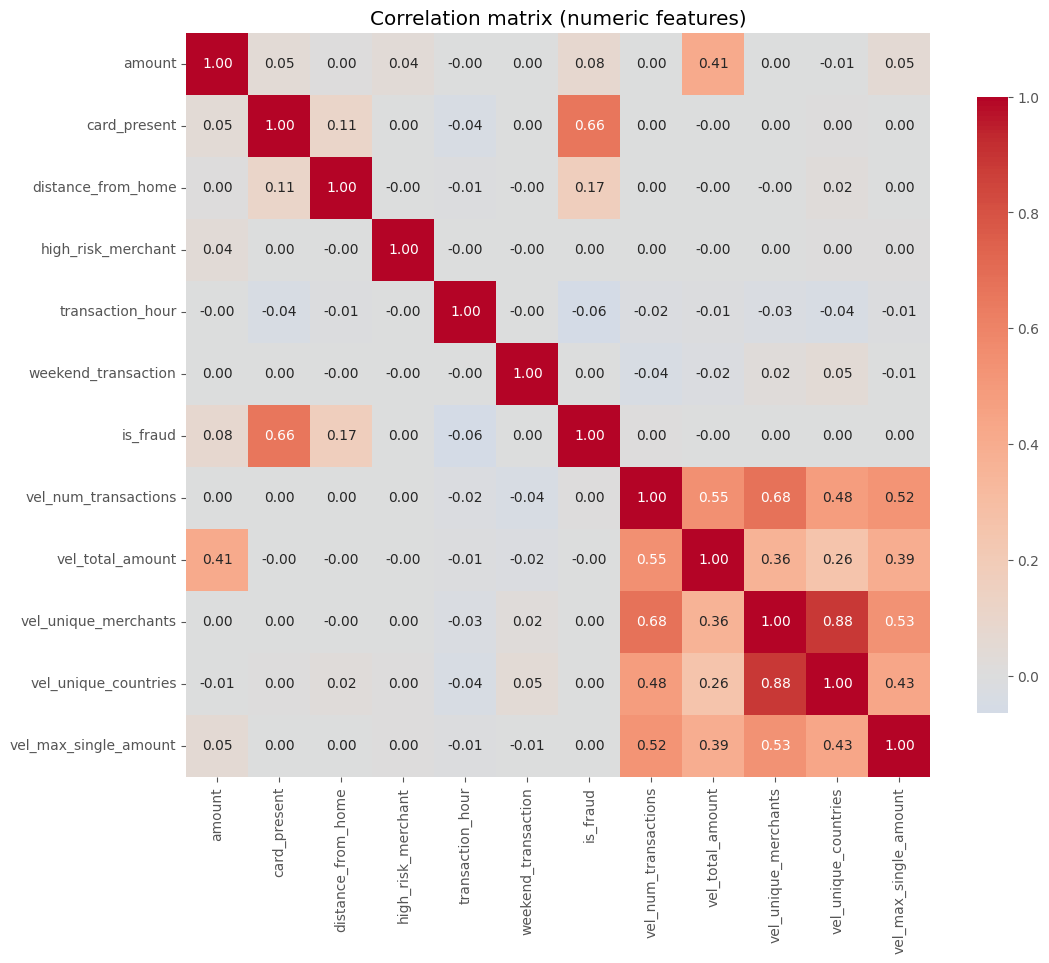

In [22]:
# Correlation matrix on numeric columns (incl. the int-encoded booleans)
num_cols = tx.select_dtypes(include=[np.number]).columns.tolist()
corr = tx[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation matrix (numeric features)")
plt.show()

### Association matrix including categorical features

The `corr()` heatmap above only covers numeric columns. Pearson on label-encoded categories would be invalid (it invents an order that doesn't exist), so for **mixed types** we pick the right statistic per pair and assemble a single matrix:

| pair | measure | range |
|------|---------|-------|
| numeric ↔ numeric | **\|Spearman\|** (rank-based, robust to the heavy skew in `amount`/`vel_*`) | 0–1 |
| categorical ↔ categorical | **Cramér's V** (Bergsma bias-corrected) | 0–1 |
| categorical ↔ numeric | **correlation ratio η** | 0–1 |

All entries are **association magnitudes in [0, 1]** (no sign/direction). The **leaking columns `card_present`, `channel` and `device` are excluded** (perfect separators — see the leakage check above), along with the remaining high-cardinality identifiers `merchant` and `city` (`customer_id` was already dropped in the cleaning step). The int-encoded binary flags are treated as categorical.

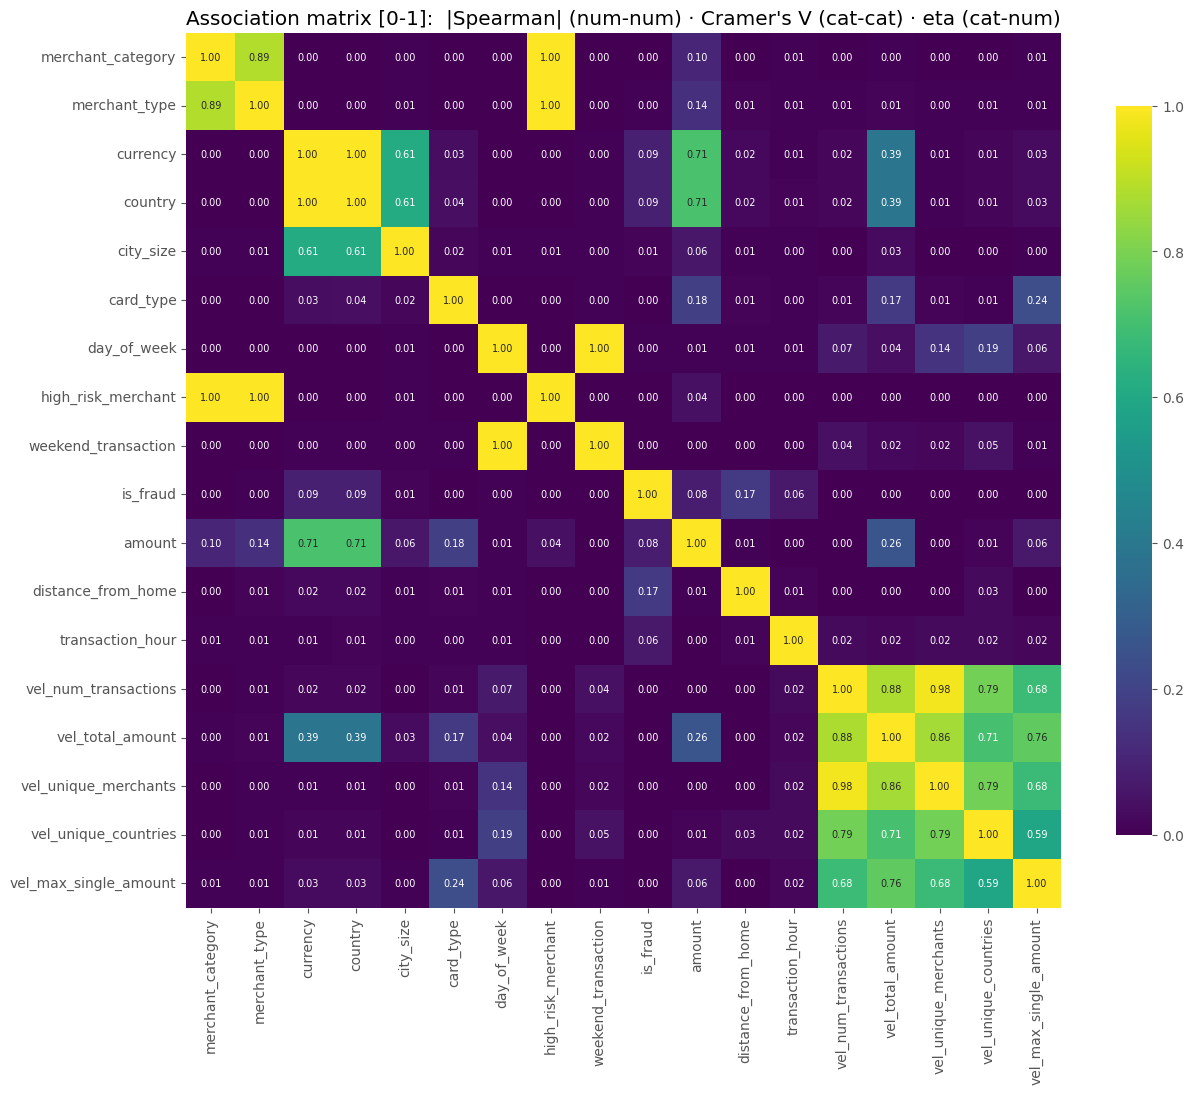

In [23]:
from itertools import combinations
from scipy.stats import chi2_contingency

# Feature set: leaking cols (card_present, channel, device) and high-cardinality ids
# (merchant, city; customer_id already dropped in cleaning) are excluded.
assoc_cat = ["merchant_category", "merchant_type", "currency", "country", "city_size",
             "card_type", "day_of_week", "high_risk_merchant",
             "weekend_transaction", "is_fraud"]
assoc_num = ["amount", "distance_from_home", "transaction_hour", "vel_num_transactions",
             "vel_total_amount", "vel_unique_merchants", "vel_unique_countries",
             "vel_max_single_amount"]


def cramers_v(x, y):
    """Cramer's V for two categoricals, with Bergsma (2013) bias correction. Range [0, 1]."""
    cm = pd.crosstab(x, y)
    n = cm.values.sum()
    chi2 = chi2_contingency(cm)[0]
    phi2 = chi2 / n
    r, k = cm.shape
    phi2_corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2_corr / max(1e-12, min(k_corr - 1, r_corr - 1)))


def correlation_ratio(categories, values):
    """Correlation ratio eta for categorical vs numeric (sqrt of ANOVA eta^2). Range [0, 1]."""
    g = values.groupby(categories)
    ss_between = (g.count() * (g.mean() - values.mean()) ** 2).sum()
    ss_total = ((values - values.mean()) ** 2).sum()
    return np.sqrt(ss_between / ss_total) if ss_total else 0.0


_cols = assoc_cat + assoc_num
_cset, _nset = set(assoc_cat), set(assoc_num)
assoc = pd.DataFrame(np.eye(len(_cols)), index=_cols, columns=_cols)
for a, b in combinations(_cols, 2):
    if a in _cset and b in _cset:          # cat - cat
        v = cramers_v(tx[a], tx[b])
    elif a in _nset and b in _nset:        # num - num (|Spearman|, robust to skew)
        v = abs(tx[a].corr(tx[b], method="spearman"))
    else:                                  # cat - num (correlation ratio)
        c, n = (a, b) if a in _cset else (b, a)
        v = correlation_ratio(tx[c], tx[n])
    assoc.loc[a, b] = assoc.loc[b, a] = v

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(assoc, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1,
            square=True, annot_kws={"size": 7}, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Association matrix [0-1]:  |Spearman| (num-num) · Cramer's V (cat-cat) · eta (cat-num)")
fig.tight_layout()
plt.show()

### Mutual information with `is_fraud`

Association strength is symmetric and pairwise; **mutual information** is a model-agnostic measure of how much knowing a feature reduces uncertainty about the target, and it captures **non-linear / non-monotonic** dependence that Spearman and η can miss. Computed against `is_fraud` with the same leak-free feature set (categoricals integer-coded and flagged as discrete). Higher = more informative.

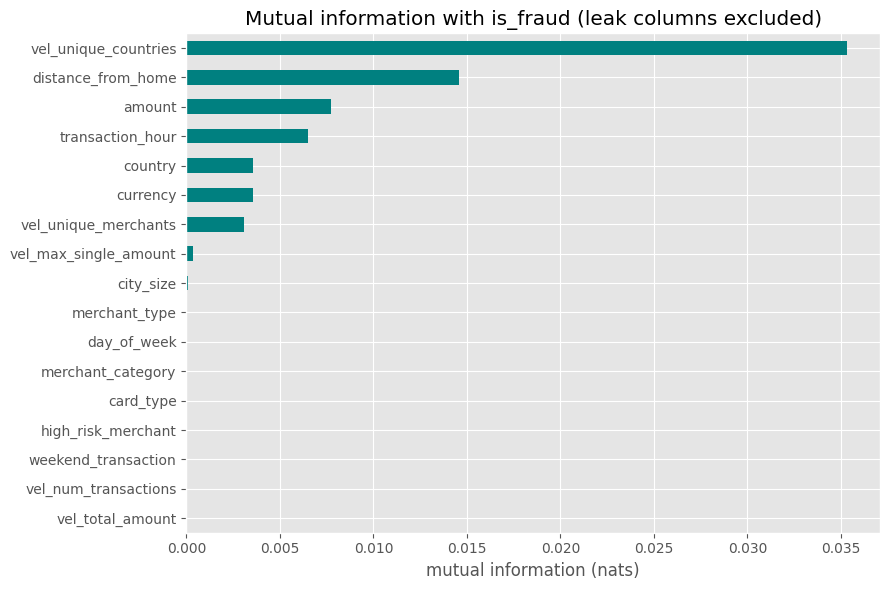

vel_unique_countries     0.03532
distance_from_home       0.01456
amount                   0.00774
transaction_hour         0.00650
country                  0.00355
currency                 0.00355
vel_unique_merchants     0.00307
vel_max_single_amount    0.00037
city_size                0.00007
merchant_type            0.00004
day_of_week              0.00002
merchant_category        0.00002
card_type                0.00001
high_risk_merchant       0.00000
weekend_transaction      0.00000
vel_num_transactions     0.00000
vel_total_amount         0.00000
dtype: float64

In [24]:
from sklearn.feature_selection import mutual_info_classif

# Same feature set as the association matrix (leaks + ids already excluded), minus the target
mi_cat = [c for c in assoc_cat if c != "is_fraud"]
X_mi = pd.DataFrame(index=tx.index)
discrete_mask = []
for c in mi_cat:                      # categoricals -> integer codes, flagged as discrete
    X_mi[c] = tx[c].astype("category").cat.codes
    discrete_mask.append(True)
for c in assoc_num:                   # numerics passed through as continuous
    X_mi[c] = tx[c]
    discrete_mask.append(False)

mi = mutual_info_classif(X_mi, tx["is_fraud"],
                         discrete_features=discrete_mask, random_state=RANDOM_STATE)
mi_scores = pd.Series(mi, index=mi_cat + assoc_num).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
mi_scores.iloc[::-1].plot(kind="barh", color="teal", ax=ax)
ax.set_title("Mutual information with is_fraud (leak columns excluded)")
ax.set_xlabel("mutual information (nats)")
fig.tight_layout()
plt.show()
mi_scores.round(5)

In [25]:
# Pearson correlation of each numeric feature with the target
corr["is_fraud"].drop("is_fraud").sort_values(key=np.abs, ascending=False)

card_present             0.656610
distance_from_home       0.166653
amount                   0.077103
transaction_hour        -0.064142
vel_num_transactions     0.002835
high_risk_merchant       0.002273
vel_max_single_amount    0.002245
vel_unique_countries     0.001847
weekend_transaction      0.001752
vel_unique_merchants     0.001374
vel_total_amount        -0.000930
Name: is_fraud, dtype: float64

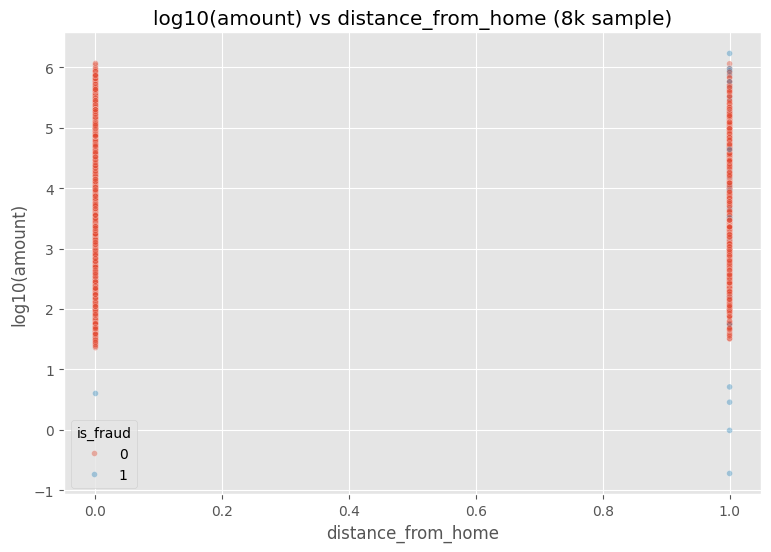

In [26]:
# Scatter: amount vs distance_from_home, coloured by fraud (sampled for legibility)
samp = tx.sample(n=8000, random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=samp, x="distance_from_home", y=np.log10(samp["amount"].clip(lower=0.01)),
                hue="is_fraud", alpha=0.4, s=18, ax=ax)
ax.set_title("log10(amount) vs distance_from_home (8k sample)")
ax.set_ylabel("log10(amount)")
plt.show()

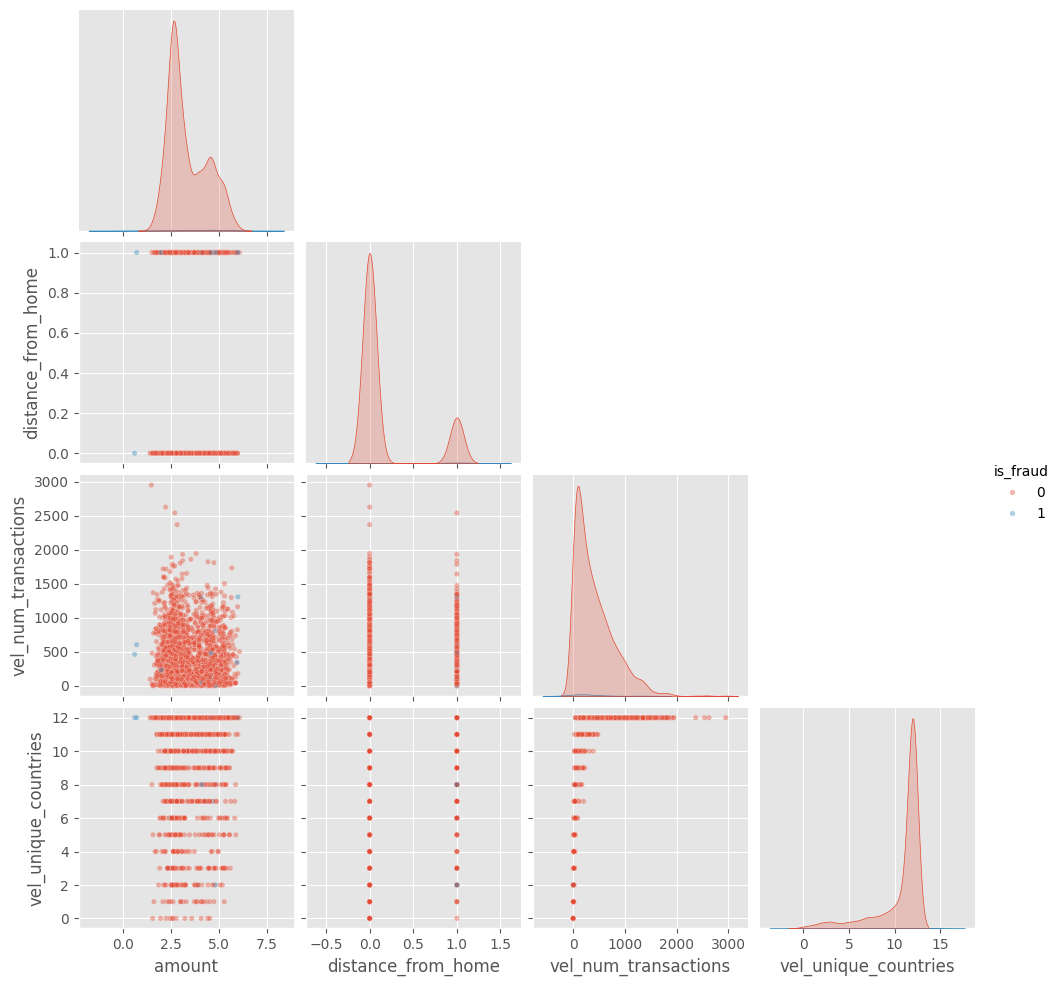

In [27]:
# Pairplot on a small numeric subset, coloured by fraud
pair_vars = ["amount", "distance_from_home", "vel_num_transactions", "vel_unique_countries"]
pp = tx.sample(n=2500, random_state=RANDOM_STATE).copy()
pp["amount"] = np.log10(pp["amount"].clip(lower=0.01))
sns.pairplot(pp, vars=pair_vars, hue="is_fraud", corner=True,
             plot_kws={"alpha": 0.4, "s": 15})
plt.show()

## EDA-5. Ask a Question

**Q: Which merchant categories carry the highest fraud rate** (among categories with a meaningful number of transactions)?

In [28]:
by_cat = (
    tx.groupby("merchant_category")["is_fraud"]
      .agg(fraud_rate="mean", n="count")
      .query("n >= 500")
      .sort_values("fraud_rate", ascending=False)
)
by_cat["fraud_rate"] = (by_cat["fraud_rate"] * 100).round(3)
by_cat

,fraud_rate,n
merchant_category,,
Healthcare,0.817,30215
Travel,0.790,30396
Entertainment,0.779,30314
Gas,0.756,30170
Education,0.749,30297
Grocery,0.748,30070
Retail,0.714,30404
Restaurant,0.648,29804


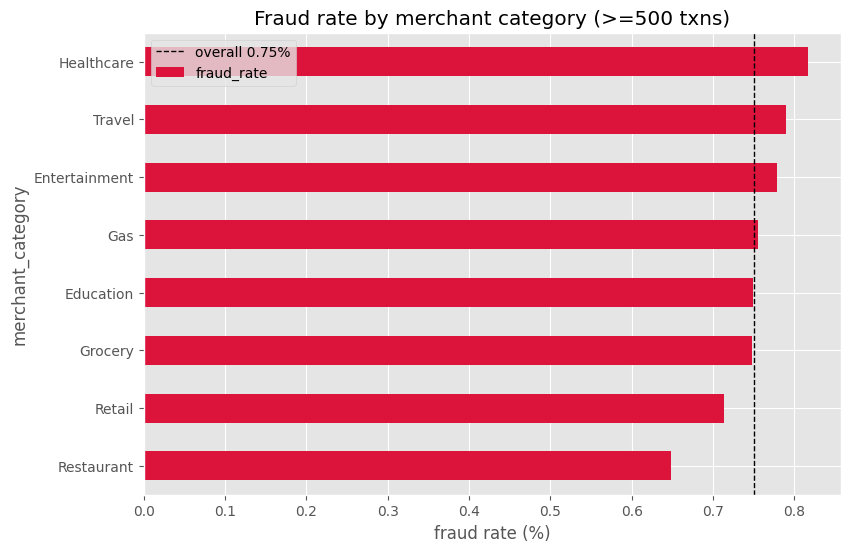

In [29]:
fig, ax = plt.subplots(figsize=(9, 6))
by_cat["fraud_rate"].iloc[::-1].plot(kind="barh", color="crimson", ax=ax)
ax.axvline(tx["is_fraud"].mean() * 100, color="black", ls="--", lw=1,
           label=f"overall {tx['is_fraud'].mean()*100:.2f}%")
ax.set_title("Fraud rate by merchant category (>=500 txns)")
ax.set_xlabel("fraud rate (%)")
ax.set_ylabel("merchant_category")
ax.legend()
plt.show()

**Follow-up:** fraud rate by a couple of other dimensions — `high_risk_merchant` flag and `card_present`.

In [30]:
for c in ["high_risk_merchant", "card_present", "channel", "weekend_transaction"]:
    rate = (tx.groupby(c)["is_fraud"].mean() * 100).round(3)
    print(f"--- fraud rate (%) by {c} ---")
    print(rate, "\n")

--- fraud rate (%) by high_risk_merchant ---
high_risk_merchant
0    0.739
1    0.784
Name: is_fraud, dtype: float64 

--- fraud rate (%) by card_present ---
card_present
0      0.427
1    100.000
Name: is_fraud, dtype: float64 

--- fraud rate (%) by channel ---
channel
mobile      0.418
pos       100.000
web         0.431
Name: is_fraud, dtype: float64 

--- fraud rate (%) by weekend_transaction ---
weekend_transaction
0    0.741
1    0.776
Name: is_fraud, dtype: float64 



## 6. Remove leaked columns → modeling-ready frame

Drop the verified perfect-separator columns (`LEAK_COLS`) to produce **`tx_model`**, the frame to carry into feature engineering / modeling. Keeping them would let a model "cheat" — e.g. `card_present == True` ⇒ fraud at 100% accuracy — which never generalises to real card-not-present scoring.

In [31]:
tx_model = tx.drop(columns=[c for c in LEAK_COLS if c in tx.columns]).copy()
print("Dropped leaked columns:", LEAK_COLS)
print("tx       (with leaks):", tx.shape)
print("tx_model (leak-free) :", tx_model.shape)
print(f"tx_model fraud rate  : {tx_model['is_fraud'].mean() * 100:.3f}%")
list(tx_model.columns)

Dropped leaked columns: ['card_present', 'channel', 'device']
tx       (with leaks): (241670, 25)
tx_model (leak-free) : (241670, 22)
tx_model fraud rate  : 0.750%


['timestamp',
 'merchant_category',
 'merchant_type',
 'merchant',
 'amount',
 'currency',
 'country',
 'city',
 'city_size',
 'card_type',
 'distance_from_home',
 'high_risk_merchant',
 'transaction_hour',
 'weekend_transaction',
 'is_fraud',
 'date',
 'day_of_week',
 'vel_num_transactions',
 'vel_total_amount',
 'vel_unique_merchants',
 'vel_unique_countries',
 'vel_max_single_amount']

### Takeaways
- The realistic-imbalance copy `transaction_sampled_v2` sits at ~0.75% fraud (saved to `transaction_sampled_v2.csv`).
- No missing values; identifier columns dropped; `velocity_last_hour` parsed into 5 numeric features; `timestamp` parsed to datetime.
- `amount` is in mixed local currencies and extremely right-skewed — analyze on a log scale (or normalize to a common currency before modeling).
- Inspect the target-correlation ranking and the fraud-rate-by-category chart above for the strongest candidate signals to take into feature engineering / modeling.
- **Target leakage found, verified on the full 7.48M-row dataset, and removed:** `card_present` (`True`), `channel` (`pos`) and `device` (`Chip Reader` / `Magnetic Stripe` / `NFC Payment`) are 100% fraud — all the same card-present rows. Dropped into `tx_model` (see §6).